# Satellite-to-satellite baseline

A naive concat zero-shot DiffusionSat baseline.

---

**TL;DR**

Zero-shot satellite-to-satellite with DiffusionSat UNet works well (~0.79 R@1 on 512 locations).

`down_blocks` attention blocks is the best feature source for the SeCo dataset. Encoder features > decoder features in UNet. Adding more blocks weakens signal. Convolution blocks show worse performance than attention blocks. Combining both performs worse than just attention blocks. Network bottleneck doesn't matter much.

3 noisy timesteps ([48, 46, 42]) is the best. Later research should also inspect whether less or even noisier timesteps will be reasonable.

Global average pooling vs generalized mean pooling matters marginally for attention features.

Notes:

- this was a limited sample size experiment (512 samples)
- other datasets might require other setup of hyperparams
- I guess attention blocks being more significant than conv blocks makes sense given we rely on spatial dims. However, this probably will change when we use shifted/cropped/UAV-like/UAV images for retrieval, in that case conv blocks might shine too. Domain shift in this dataset is small, afterall
- this experiment ran over raw features (pooled but still) and the dimensions were not reduced in any way. a trained head might perform better
- for performance consideration, we could reduce `num_timesteps` and search for optimal `save_timesteps` in that case.


## Preparation


In [1]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!git clone https://github.com/yugisu/SatDiFuser.git
!cd SatDiFuser && git checkout 35d87ca675e2a7519508d778062fc43525fa889d # old `research` branch commit

import sys

sys.path.append("./SatDiFuser")

fatal: destination path 'SatDiFuser' already exists and is not an empty directory.
Already on 'yugisu/retrieval'
Your branch is up to date with 'origin/yugisu/retrieval'.


In [3]:
# Modified SatDiFuser/requirements.txt
!uv pip install \
    numpy==1.26.3 \
    diffusers==0.17.0 \
    torch==2.2.2 \
    torchvision==0.17.2 \
    accelerate==0.18.0 \
    transformers==4.40.0 \
    scikit-learn==1.5.2 \
    huggingface_hub==0.19.3 \
    h5py==3.11.0 \
    tensorboard \
    wandb \
    omegaconf \
    matplotlib \
    fvcore \
    rasterio \
    omegaconf \
    faiss-cpu

# Addressing `diffusionsat` and `diffusers` import issues
!uv pip install "jax[cuda12_local]==0.4.23" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
!uv pip uninstall flax

# RESTART THE NOTEBOOK AFTER INSTALL

Using Python 3.12.12 environment at: /usr
Audited 17 packages in 101ms
Using Python 3.12.12 environment at: /usr
Audited 1 package in 91ms
Using Python 3.12.12 environment at: /usr


In [4]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import torch
import torch.nn.functional as F
from PIL import Image
from torch import nn
from torchvision import transforms
from tqdm import tqdm

warnings.filterwarnings(
  "ignore", category=SyntaxWarning, message=".*invalid escape sequence.*"
)

DEVICE = torch.device("cuda")
SECO_ROOT = Path("./seasonal_contrast_100k")

## Data


In [5]:
# Copy SeCo dataset from Google Drive and unzip.
if not SECO_ROOT.exists():
  !cp "/content/drive/MyDrive/datasets/seco_100k.zip" "seco_100k.zip" && unzip -q -n "seco_100k.zip"
else:
  print(f'"{SECO_ROOT}" already exists. Skipping copy and unzip.')


"seasonal_contrast_100k" already exists. Skipping copy and unzip.


In [6]:
# Sentinel-2 band names and RGB subset (natural colour: R=B4, G=B3, B=B2)
ALL_BANDS = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B9", "B11", "B12"]
RGB_BANDS = ["B4", "B3", "B2"]

# Per-band quantiles used to stretch raw uint16 values to [0, 255]
QUANTILES = {
  "min_q": {"B2": 3.0, "B3": 2.0, "B4": 0.0},
  "max_q": {"B2": 88.0, "B3": 103.0, "B4": 129.0},
}


def normalize(arr: np.ndarray, min_q: float, max_q: float) -> np.ndarray:
  """Stretch [min_q, max_q] → [0, 255] uint8."""
  return np.clip((arr - min_q) / (max_q - min_q) * 255.0, 0, 255).astype(np.uint8)


def read_image(
  path: Path,
  bands: list[str],
  quantiles: dict | None = None,
) -> tuple[Image.Image, float, float]:
  """Load a multi-band SeCo patch as a PIL Image with its centre lat/lon."""
  channels, lat, lon = [], float("nan"), float("nan")
  for i, band in enumerate(bands):
    with rasterio.open(path / f"{band}.tif") as src:
      ch = src.read(1)
      if i == 0:
        h, w = ch.shape
        t = src.transform
        lon = t.c + (w / 2) * t.a + (h / 2) * t.b
        lat = t.f + (h / 2) * t.e + (w / 2) * t.d
    if quantiles is not None:
      ch = normalize(ch, quantiles["min_q"][band], quantiles["max_q"][band])
    channels.append(ch)
  return Image.fromarray(np.dstack(channels)), float(lat), float(lon)


class SeCoDataset(torch.utils.data.Dataset):
  """Seasonal Contrast (SeCo) dataset. Provide acq_indices to select specific seasons per location."""

  def __init__(
    self,
    root: str | Path,
    bands: list[str] | None = None,
    acq_indices: list[int] | int | None = None,
    transform: transforms.Compose | None = None,
  ) -> None:
    self.root = Path(root)
    self.bands = bands if bands is not None else RGB_BANDS
    self.acq_indices = acq_indices
    self.transform = transform
    self._locations: list[list[Path]] = [
      sorted(Path(acq.path) for acq in os.scandir(loc.path) if acq.is_dir())
      for loc in os.scandir(self.root)
      if loc.is_dir()
    ]

  def __len__(self) -> int:
    return len(self._locations)

  def _load(self, path: Path) -> tuple[Image.Image, float, float]:
    img, lat, lon = read_image(path, self.bands, QUANTILES)
    if self.transform is not None:
      img = self.transform(img)
    return img, lat, lon

  def __getitem__(
    self, index: int
  ) -> tuple[list[Image.Image] | Image.Image, float, float]:
    if isinstance(self.acq_indices, int):
      return self._load(self._locations[index][self.acq_indices])

    acq_paths = self._locations[index]
    if self.acq_indices is not None:
      acq_paths = [acq_paths[i] for i in self.acq_indices]

    loaded = [self._load(p) for p in acq_paths]
    images = [img for img, _, _ in loaded]
    _, lat, lon = loaded[-1]
    return images, lat, lon

## Definitions


In [7]:
# Defaults for LDM feature extraction.


from omegaconf import OmegaConf
from archs.ldm_extractor import LDMExtractor


def ldm_extractor_cfg(
  img_size=256,
  batch_size=16,
  save_timesteps=[47, 45, 40],
  layer_idxs={"up_blocks": {"attn1": "all", "conv2": "all"}},
  num_timesteps=50,
  diffusion_mode="inversion",
  prompt="A satellite image",
  negative_prompt="",
  resize_outputs=-1,
  max_i=None,
  min_i=None,
) -> OmegaConf:
  cfg: dict = {
    "num_timesteps": num_timesteps,
    "save_timesteps": save_timesteps,
    "batch_size": batch_size,
    "img_size": img_size,
    "resize_outputs": resize_outputs,
    "diffusion_mode": diffusion_mode,
    "layer_idxs": layer_idxs,
    "prompt": prompt,
    "negative_prompt": negative_prompt,
  }
  if max_i is not None:
    cfg["max_i"] = max_i
  if min_i is not None:
    cfg["min_i"] = min_i

  return OmegaConf.create(cfg)


In [8]:
# Embedding heads.


def gap_pool(x):
  """Global average pooling."""
  return F.adaptive_avg_pool2d(x.float(), 1).flatten(1)


def gem_pool(x, p=3, eps=1e-6):
  """Generalized mean pooling. https://arxiv.org/abs/1711.02512"""
  return (
    F.avg_pool2d(x.clamp(min=eps).pow(p), (x.size(-2), x.size(-1)))
    .pow(1.0 / p)
    .flatten(1)
  )


class PoolEmbedder(nn.Module):
  """Embedder that consumes layer features and applies a pooling operation to produce a fixed-size embedding vector."""

  def __init__(
    self,
    feature_dims: dict,
    save_timesteps: list,
    normalize_embeddings: bool = True,
    **kwargs,
  ):
    super().__init__()
    self.normalize_embeddings = normalize_embeddings
    self.save_timesteps = save_timesteps

    total_channels = sum(sum(dims) for dims in feature_dims.values()) * len(
      save_timesteps
    )
    self.embedding_dim = total_channels

  def _pool(self, x):
    raise NotImplementedError

  def forward(self, feats: dict):
    pooled_vectors = []

    for ts in sorted(feats.keys()):
      for scale_feat in feats[ts]:
        pooled = self._pool(scale_feat)
        pooled_vectors.append(pooled)

    embedding = torch.cat(pooled_vectors, dim=1)

    if self.normalize_embeddings:
      embedding = F.normalize(embedding, p=2, dim=1)

    return embedding


class ConcatGAPEmbedder(PoolEmbedder):
  def _pool(self, x):
    return gap_pool(x)


class ConcatGeMEmbedder(PoolEmbedder):
  def __init__(self, gem_p: float = 3.0, **kwargs):
    super().__init__(**kwargs)
    self.gem_p = gem_p

  def _pool(self, x):
    return gem_pool(x, p=self.gem_p)


In [9]:
# Retriever.


import faiss


class FAISSRetriever:
  def __init__(self, gallery_embeddings: torch.Tensor):
    self.gallery_embeddings = gallery_embeddings
    self.index = faiss.IndexFlatIP(gallery_embeddings.shape[1])
    g_np = np.ascontiguousarray(
      gallery_embeddings.detach().cpu().numpy().astype(np.float32)
    )
    self.index.add(g_np)

  def search(self, query_embeddings: torch.Tensor, k: int = 10):
    q_np = np.ascontiguousarray(
      query_embeddings.detach().cpu().numpy().astype(np.float32)
    )
    distances, indices = self.index.search(q_np, k)
    return distances, indices


In [10]:
# Evaluation.


def recall_at_k(preds: np.ndarray, truth: np.ndarray, k: int) -> float:
  hits = np.any(preds[:, :k] == truth[:, None], axis=1)
  return hits.mean()


def calculate_metrics(preds: np.ndarray, truth: np.ndarray) -> dict:
  metrics = {
    "Recall@1": recall_at_k(preds, truth, k=1),
    "Recall@5": recall_at_k(preds, truth, k=5),
    "Recall@10": recall_at_k(preds, truth, k=10),
  }
  return metrics

## Main

Perform satellite-to-satellite retrieval for locations based on pictures taken during different times.

This section does a grid search for optimal configuration of feature extraction.

We use 256x256 checkpoint because SeCo has sizes of 264x264 pixels.


In [11]:
# DiffusionSat model initialization.


DIFFUSIONSAT_CHKPTS = Path("/content/drive/MyDrive/diffusionsat-checkpoints")
chkpt256 = DIFFUSIONSAT_CHKPTS / "finetune_sd21_256_sn-satlas-fmow_snr5_md7norm_bs64"
chkpt512 = DIFFUSIONSAT_CHKPTS / "finetune_sd21_sn-satlas-fmow_snr5_md7norm_bs64"

chkpt = chkpt256
revision = None


from diffusionsat import SatUNet, DiffusionSatPipeline
from diffusers import AutoencoderKL


unet = SatUNet.from_pretrained(
  chkpt,
  subfolder="checkpoint-150000/unet",
  revision=revision,
  num_metadata=0,
  use_metadata=False,
  low_cpu_mem_usage=False,
)
unet.requires_grad_(False)
unet.to(DEVICE)

pipe = DiffusionSatPipeline.from_pretrained(chkpt, unet=unet, low_cpu_mem_usage=False)
pipe.to(DEVICE)

vae = AutoencoderKL.from_pretrained(chkpt, subfolder="vae", revision=revision)
vae.requires_grad_(False)
vae.to(DEVICE);


/usr/local/lib/python3.12/dist-packages/diffusers/models/cross_attention.py:30: FutureWarning: Importing from cross_attention is deprecated. Please import from diffusers.models.attention_processor instead.
  deprecate(
Some weights of the model checkpoint at /content/drive/MyDrive/diffusionsat-checkpoints/finetune_sd21_256_sn-satlas-fmow_snr5_md7norm_bs64 were not used when initializing SatUNet: ['metadata_embedding.2.linear_2.bias', 'metadata_embedding.3.linear_1.weight', 'metadata_embedding.5.linear_2.weight', 'metadata_embedding.3.linear_1.bias', 'metadata_embedding.3.linear_2.bias', 'metadata_embedding.1.linear_1.weight', 'metadata_embedding.1.linear_2.bias', 'metadata_embedding.2.linear_1.weight', 'metadata_embedding.3.linear_2.weight', 'metadata_embedding.4.linear_1.bias', 'metadata_embedding.5.linear_2.bias', 'metadata_embedding.1.linear_2.weight', 'metadata_embedding.6.linear_1.bias', 'metadata_embedding.2.linear_1.bias', 'metadata_embedding.5.linear_1.weight', 'metadata_embedd

In [12]:
# Precompute latents for all images.


BATCH_SIZE = 64
N_SAMPLES = 512

# Define data.
transform = transforms.Compose(
  [
    transforms.Resize(
      (256, 256),
      interpolation=transforms.InterpolationMode.BILINEAR,
      antialias=True,
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
  ]
)

full_dataset = SeCoDataset(SECO_ROOT, acq_indices=[0, -1], transform=transform)
subset = torch.utils.data.Subset(full_dataset, range(N_SAMPLES))
loader = torch.utils.data.DataLoader(subset, batch_size=BATCH_SIZE, shuffle=False)

num_acqs = 2
num_locs = len(subset)


# Pre-compute VAE latents once
all_latents = []
with torch.inference_mode():
  g = torch.Generator(device=DEVICE).manual_seed(0)

  for batch, _, _ in tqdm(loader, desc="Pre-compute latents"):
    imgs_ = torch.stack(batch).permute(1, 0, 2, 3, 4).flatten(0, 1).to(DEVICE)
    all_latents.append(vae.encode(imgs_).latent_dist.sample(generator=g) * 0.18215)


Pre-compute latents: 100%|██████████| 8/8 [00:10<00:00,  1.28s/it]


In [13]:
# Grid search.


from itertools import product


grid = {
  # Which diffusion timesteps to extract features from. Should be a subset of the 50 DDIM timesteps used for inversion.
  # Larger = noisier, smaller = closer to input image.
  "save_timesteps": [
    [47, 45, 40],
    [49, 47, 45, 40, 35],
    [48, 46, 42],
    # [40, 30, 20],
    # [20, 10, 5],
  ],
  # Which SatUNet layers to extract features from.
  "layer_idxs": [
    {"down_blocks": {"attn1": "all"}},
    {"up_blocks": {"attn1": "all"}},
    {"mid_block": {"attn1": "all"}},
    {
      "down_blocks": {"attn1": "all"},
      "mid_block": {"attn1": "all"},
      "up_blocks": {"attn1": "all"},
    },
    # {"mid_block": {"attn1": "all"}, "up_blocks": {"attn1": "all"}},
    # {"down_blocks": {"attn1": "all"}, "up_blocks": {"attn1": "all"}},
    # {"up_blocks": {"conv2": "all"}},
    # {"up_blocks": {"attn1": "all", "conv2": "all"}},
  ],
  "embedder": [
    "ConcatGAP",
    "ConcatGeM",
  ],
}


results = []
configs = list(product(grid["save_timesteps"], grid["layer_idxs"], grid["embedder"]))

for save_timesteps, layer_idxs, emb in tqdm(configs, desc="Grid search"):
  cfg = ldm_extractor_cfg(
    save_timesteps=save_timesteps,
    layer_idxs=layer_idxs,
  )
  ldm_extractor = LDMExtractor(cfg, pipe)

  if emb == "ConcatGAP":
    embedder = ConcatGAPEmbedder(
      feature_dims=ldm_extractor.collected_dims,
      save_timesteps=save_timesteps,
      normalize_embeddings=True,
    )
  elif emb == "ConcatGeM":
    embedder = ConcatGeMEmbedder(
      gem_p=3.0,
      feature_dims=ldm_extractor.collected_dims,
      save_timesteps=save_timesteps,
      normalize_embeddings=True,
    )

  embeddings = []
  for latents_batch in all_latents:
    batch_layer_feats, _ = ldm_extractor.forward(latents_batch)
    batch_embeddings = embedder(batch_layer_feats)
    embeddings.append(batch_embeddings.cpu())

  embeddings = torch.cat(embeddings, dim=0)

  gallery, query = embeddings.view(num_locs, num_acqs, -1).unbind(dim=1)

  retriever = FAISSRetriever(gallery)
  _, preds = retriever.search(query, k=10)

  row = {
    "save_timesteps": str(save_timesteps),
    "layer_idxs": str(layer_idxs),
    "embedder": emb,
    "emb_dim": batch_embeddings.shape[-1],
    "n_samples": N_SAMPLES,
    "normalize_embeddings": embedder.normalize_embeddings,
    **calculate_metrics(preds, np.arange(len(query))),
  }
  results.append(row)

df = pd.DataFrame(results).sort_values("Recall@1", ascending=False)
df

Grid search: 100%|██████████| 24/24 [08:35<00:00, 21.47s/it]


,save_timesteps,layer_idxs,embedder,emb_dim,n_samples,normalize_embeddings,Recall@1,Recall@5,Recall@10
17,"[48, 46, 42]",{'down_blocks': {'attn1': 'all'}},ConcatGeM,13440,512,True,0.789062,0.822266,0.839844
1,"[47, 45, 40]",{'down_blocks': {'attn1': 'all'}},ConcatGeM,13440,512,True,0.787109,0.820312,0.841797
9,"[49, 47, 45, 40, 35]",{'down_blocks': {'attn1': 'all'}},ConcatGeM,22400,512,True,0.785156,0.818359,0.837891
0,"[47, 45, 40]",{'down_blocks': {'attn1': 'all'}},ConcatGAP,13440,512,True,0.783203,0.820312,0.843750
8,"[49, 47, 45, 40, 35]",{'down_blocks': {'attn1': 'all'}},ConcatGAP,22400,512,True,0.779297,0.824219,0.839844
16,"[48, 46, 42]",{'down_blocks': {'attn1': 'all'}},ConcatGAP,13440,512,True,0.779297,0.820312,0.835938
18,"[48, 46, 42]",{'up_blocks': {'attn1': 'all'}},ConcatGAP,20160,512,True,0.779297,0.822266,0.835938
22,"[48, 46, 42]","{'down_blocks': {'attn1': 'all'}, 'mid_block':...",ConcatGAP,37440,512,True,0.777344,0.814453,0.832031
14,"[49, 47, 45, 40, 35]","{'down_blocks': {'attn1': 'all'}, 'mid_block':...",ConcatGAP,62400,512,True,0.777344,0.820312,0.828125
2,"[47, 45, 40]",{'up_blocks': {'attn1': 'all'}},ConcatGAP,20160,512,True,0.775391,0.824219,0.835938


In [ ]:
df.to_csv("1-baseline-s2s-diffusionsat-naive-results.csv", index=False)
!cat 1-baseline-s2s-diffusionsat-naive-results.csv

save_timesteps,layer_idxs,embedder,emb_dim,n_samples,normalize_embeddings,Recall@1,Recall@5,Recall@10
"[48, 46, 42]",{'down_blocks': {'attn1': 'all'}},ConcatGeM,13440,512,True,0.7890625,0.822265625,0.83984375
"[47, 45, 40]",{'down_blocks': {'attn1': 'all'}},ConcatGeM,13440,512,True,0.787109375,0.8203125,0.841796875
"[49, 47, 45, 40, 35]",{'down_blocks': {'attn1': 'all'}},ConcatGeM,22400,512,True,0.78515625,0.818359375,0.837890625
"[47, 45, 40]",{'down_blocks': {'attn1': 'all'}},ConcatGAP,13440,512,True,0.783203125,0.8203125,0.84375
"[49, 47, 45, 40, 35]",{'down_blocks': {'attn1': 'all'}},ConcatGAP,22400,512,True,0.779296875,0.82421875,0.83984375
"[48, 46, 42]",{'down_blocks': {'attn1': 'all'}},ConcatGAP,13440,512,True,0.779296875,0.8203125,0.8359375
"[48, 46, 42]",{'up_blocks': {'attn1': 'all'}},ConcatGAP,20160,512,True,0.779296875,0.822265625,0.8359375
"[48, 46, 42]","{'down_blocks': {'attn1': 'all'}, 'mid_block': {'attn1': 'all'}, 'up_blocks': {'attn1': 'all'}}",ConcatGAP,37440,512,T

In [ ]:
# Run best configuration and visualize the embedding pairs.

# This is the best config out of all tested on N_SAMPLES=512.
cfg = ldm_extractor_cfg(
  save_timesteps=[48, 46, 42],
  layer_idxs={"down_blocks": {"attn1": "all"}},
)


ldm_extractor = LDMExtractor(cfg, pipe)
embedder = ConcatGeMEmbedder(
  gem_p=3.0,
  feature_dims=ldm_extractor.collected_dims,
  save_timesteps=cfg["save_timesteps"],
  normalize_embeddings=True,
)


embeddings = []
for latents_batch in tqdm(all_latents):
  batch_layer_feats, _ = ldm_extractor.forward(latents_batch)
  batch_embeddings = embedder(batch_layer_feats)
  embeddings.append(batch_embeddings.cpu())

embeddings = torch.cat(embeddings, dim=0)

gallery, query = embeddings.view(num_locs, num_acqs, -1).unbind(dim=1)

retriever = FAISSRetriever(gallery)
distances, preds = retriever.search(query, k=10)

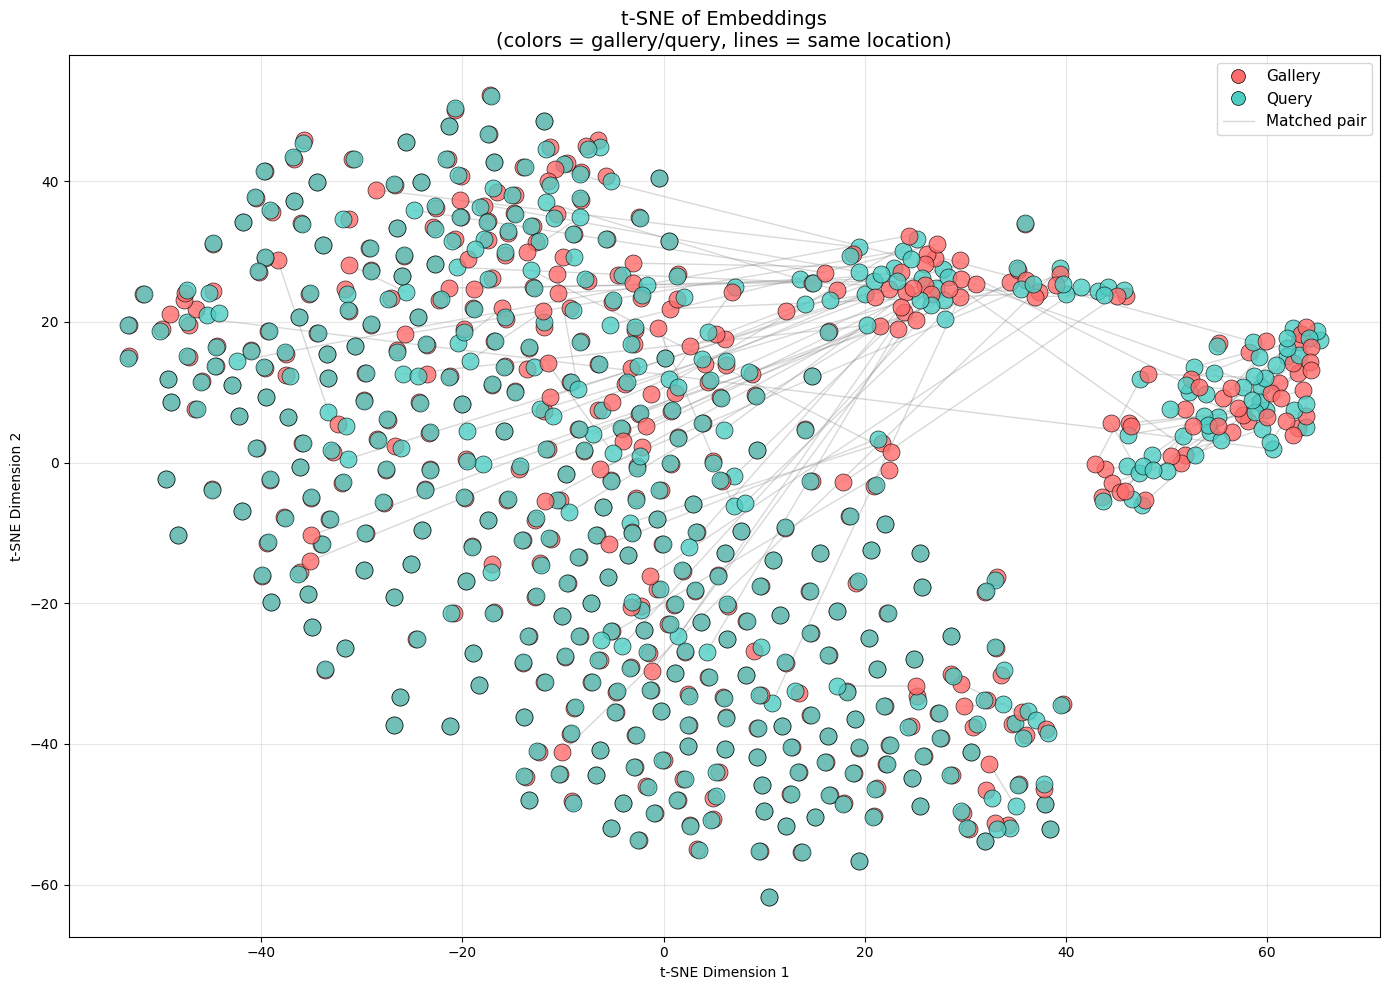

In [18]:
# fmt: off
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE


def plot_tsne(gallery: torch.Tensor, query: torch.Tensor) -> None:
  acq_colors = ["#FF6B6B", "#4ECDC4"]

  all_embeddings = torch.cat([gallery, query]).cpu().numpy()
  coords = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(all_embeddings)

  n = len(gallery)
  gallery_coords, query_coords = coords[:n], coords[n:]

  fig, ax = plt.subplots(figsize=(14, 10))

  for g_pt, q_pt in zip(gallery_coords, query_coords):
    ax.plot(*zip(g_pt, q_pt), color="gray", alpha=0.3, linewidth=1, zorder=1)
    ax.scatter(*g_pt, c=acq_colors[0], s=150, alpha=0.8, edgecolors="black", linewidth=0.5, zorder=2)
    ax.scatter(*q_pt, c=acq_colors[1], s=150, alpha=0.8, edgecolors="black", linewidth=0.5, zorder=2)

  legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=acq_colors[0], markersize=10,
           markeredgecolor="black", markeredgewidth=0.5, label="Gallery"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=acq_colors[1], markersize=10,
           markeredgecolor="black", markeredgewidth=0.5, label="Query"),
    Line2D([0], [0], color="gray", linewidth=1, alpha=0.3, label="Matched pair"),
  ]
  ax.legend(handles=legend_elements, loc="upper right", fontsize=11)
  ax.set_title("t-SNE of Embeddings\n(colors = gallery/query, lines = same location)", fontsize=14)
  ax.set_xlabel("t-SNE Dimension 1")
  ax.set_ylabel("t-SNE Dimension 2")
  ax.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()


plot_tsne(gallery, query)

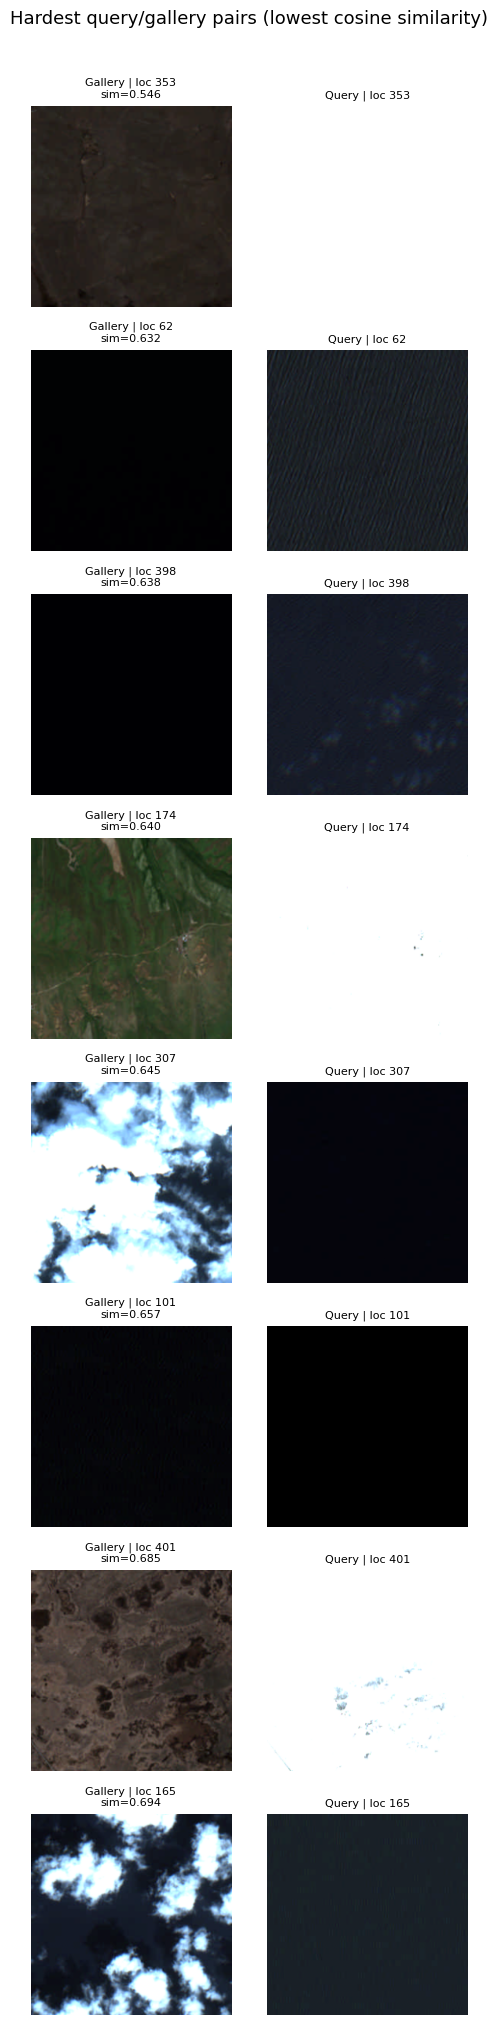

In [ ]:
# Visualize query/gallery pairs with the largest embedding distances (hardest pairs).


def visualize_hardest_pairs(
  query: torch.Tensor,
  gallery: torch.Tensor,
  dataset: torch.utils.data.Dataset,
  n: int = 8,
) -> None:
  """Show the n query/gallery pairs with the lowest cosine similarity (largest distance)."""
  # Similarity between each query[i] and its ground-truth gallery[i].
  # Both are L2-normalised, so dot product == cosine similarity.
  gt_sim = (query * gallery).sum(dim=1).cpu().numpy()  # (num_locs,)
  hardest_indices = np.argsort(gt_sim)[:n]  # ascending: lowest sim first

  # Build a display dataset (no normalization) to recover RGB images.
  display_transform = transforms.Compose(
    [
      transforms.Resize(
        (256, 256), interpolation=transforms.InterpolationMode.BILINEAR, antialias=True
      ),
      transforms.ToTensor(),
    ]
  )
  display_dataset = SeCoDataset(
    SECO_ROOT, acq_indices=[0, -1], transform=display_transform
  )

  fig, axes = plt.subplots(n, 2, figsize=(5, 2.5 * n))
  fig.suptitle(
    "Hardest query/gallery pairs (lowest cosine similarity)", fontsize=13, y=1.01
  )

  for row, idx in enumerate(hardest_indices):
    imgs, lat, lon = display_dataset[idx]
    gallery_img, query_img = imgs  # acq_indices=[0, -1]

    sim = gt_sim[idx]

    for col, (img_tensor, label) in enumerate(
      [(gallery_img, "Gallery"), (query_img, "Query")]
    ):
      ax = axes[row, col]
      ax.imshow(img_tensor.permute(1, 2, 0).numpy())
      ax.set_title(
        f"{label} | loc {idx}" + (f"\nsim={sim:.3f}" if col == 0 else ""), fontsize=8
      )
      ax.axis("off")

  plt.tight_layout()
  plt.show()


visualize_hardest_pairs(query, gallery, subset, n=8)
